## 1. Librerías y configuración




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEED = 42
rng = np.random.default_rng(SEED)


## 2. Generación de los seis grupos

Cada grupo sigue una distribución gaussiana isotrópica: la desviación estándar es la misma en X y Y y no existe covarianza entre ambas variables.

Todos los grupos tienen el mismo número de puntos (`250`), pero diferentes desviaciones estándar. Los grupos 2 y 3 tienen centros muy cercanos, por lo que se espera un solapamiento parcial.


In [2]:
n_por_grupo = 250

# Centros de los seis grupos
centros = np.array([
    [-6.0, -5.0],
    [-2.0,  2.0],
    [-0.8,  2.4],   # cercano al grupo 2
    [ 5.5,  5.0],
    [ 5.5, -5.5],
    [-5.5,  6.0]
])

# Diferentes desviaciones -> diferentes densidades
desviaciones = np.array([0.35, 0.55, 1.05, 0.75, 0.45, 0.95])

X_grupos = []
y_true_grupos = []

for i, (centro, sigma) in enumerate(zip(centros, desviaciones)):
    puntos = rng.normal(loc=centro, scale=sigma, size=(n_por_grupo, 2))
    X_grupos.append(puntos)
    y_true_grupos.extend([i] * n_por_grupo)

X_grupos = np.vstack(X_grupos)
y_true_grupos = np.array(y_true_grupos)

print("Puntos de los 6 grupos:", len(X_grupos))
print("Puntos por grupo:", n_por_grupo)
print("Desviaciones estándar:", desviaciones)


Puntos de los 6 grupos: 1500
Puntos por grupo: 250
Desviaciones estándar: [0.35 0.55 1.05 0.75 0.45 0.95]


## 3. Generación de outliers

Los outliers se generan con una distribución uniforme entre `-10` y `10` tanto para X como para Y. Se etiquetan como `-1` para distinguirlos del ground truth de los seis grupos.


In [3]:
n_outliers = 100

X_outliers = rng.uniform(-10, 10, size=(n_outliers, 2))
y_outliers = np.full(n_outliers, -1)

X = np.vstack([X_grupos, X_outliers])
y_true = np.concatenate([y_true_grupos, y_outliers])

# Garantía de que todos los valores estén dentro de [-10,10]
X = np.clip(X, -10, 10)

print("Total de observaciones:", len(X))
print("Outliers:", n_outliers)
print("Mínimo por eje:", X.min(axis=0))
print("Máximo por eje:", X.max(axis=0))


Total de observaciones: 1600
Outliers: 100
Mínimo por eje: [-9.74013303 -9.98350766]
Máximo por eje: [9.69170083 9.9203151 ]


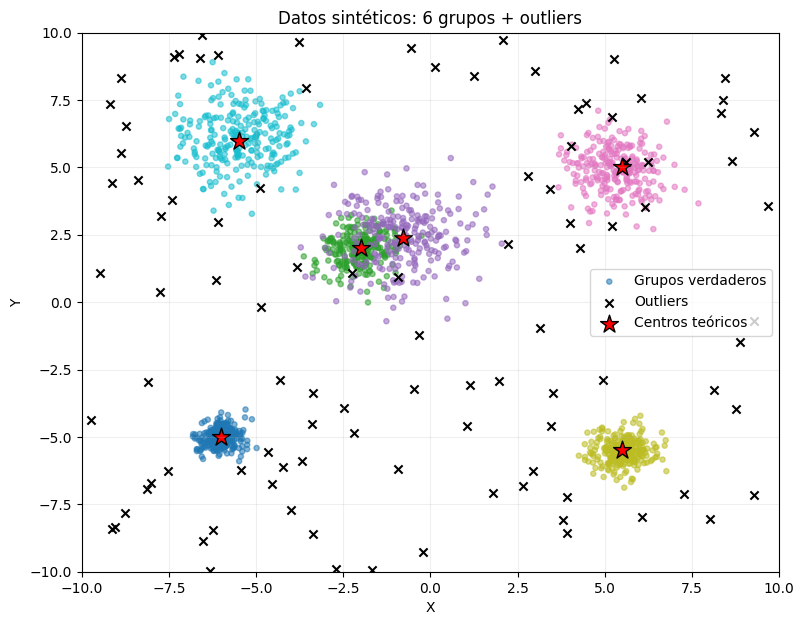

In [4]:
plt.figure(figsize=(9, 7))
plt.scatter(X_grupos[:, 0], X_grupos[:, 1], c=y_true_grupos,
            cmap="tab10", s=14, alpha=0.55, label="Grupos verdaderos")
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c="black",
            marker="x", s=35, label="Outliers")
plt.scatter(centros[:, 0], centros[:, 1], c="red",
            marker="*", s=180, edgecolor="black", label="Centros teóricos")
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos sintéticos: 6 grupos + outliers")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


## 4. Remoción de outliers

Como los datos son sintéticos y conocemos exactamente qué puntos fueron generados como outliers, se pueden remover directamente mediante su etiqueta `-1`.

En un problema real esta información no estaría disponible y sería necesario aplicar un detector de anomalías, como Isolation Forest o LOF.


In [5]:
mask_sin_outliers = y_true != -1

X_limpio = X[mask_sin_outliers]
y_true_limpio = y_true[mask_sin_outliers]

print("Antes de remover outliers:", X.shape[0])
print("Después de remover outliers:", X_limpio.shape[0])


Antes de remover outliers: 1600
Después de remover outliers: 1500


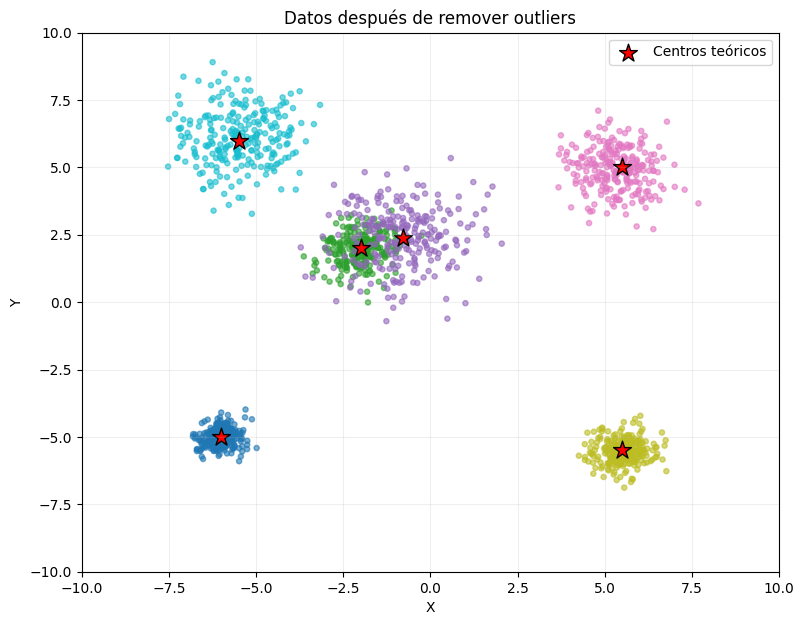

In [6]:
plt.figure(figsize=(9, 7))
plt.scatter(X_limpio[:, 0], X_limpio[:, 1], c=y_true_limpio,
            cmap="tab10", s=14, alpha=0.6)
plt.scatter(centros[:, 0], centros[:, 1], c="red",
            marker="*", s=180, edgecolor="black", label="Centros teóricos")
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos después de remover outliers")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


## 5. Exploración de K-means para k = 2,...,12

Para cada valor de `k` se registra:

- **Inercia (WCSS):** dispersión interna de los clusters; se utiliza para el método del codo.
- **Silhouette:** evalúa cohesión y separación de los clusters.
- **Adjusted Rand Index (ARI):** compara las etiquetas de K-means con el ground truth conocido.

Se utiliza `n_init=20` para disminuir el efecto de una mala inicialización de centroides.


In [7]:
ks = range(2, 13)
resultados = []
modelos = {}
etiquetas_kmeans = {}

for k in ks:
    modelo = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = modelo.fit_predict(X_limpio)

    inertia = modelo.inertia_
    silhouette = silhouette_score(X_limpio, labels)
    ari = adjusted_rand_score(y_true_limpio, labels)

    modelos[k] = modelo
    etiquetas_kmeans[k] = labels
    resultados.append([k, inertia, silhouette, ari])

resultados = pd.DataFrame(
    resultados,
    columns=["k", "Inercia_WCSS", "Silhouette", "ARI"]
)

resultados


,k,Inercia_WCSS,Silhouette,ARI
0,2,36260.271499,0.487361,0.272132
1,3,19833.335092,0.615012,0.332591
2,4,7099.848660,0.729839,0.568445
3,5,1835.142565,0.792199,0.822255
4,6,1450.955069,0.687837,0.864313
5,7,1288.988589,0.626613,0.809289
6,8,1149.151401,0.599893,0.774413
7,9,1045.976647,0.529321,0.717755
8,10,955.375220,0.525771,0.695519
9,11,860.474414,0.529400,0.680337


## 6. Método del codo

La inercia disminuye al aumentar `k`. El objetivo es encontrar el punto donde añadir más clusters deja de producir una reducción importante.

Para hacerlo reproducible, se calcula la distancia de cada punto de la curva a la recta que une el primer y último punto.


/tmp/ipykernel_4440/523946424.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.cross(linea, puntos - p1)


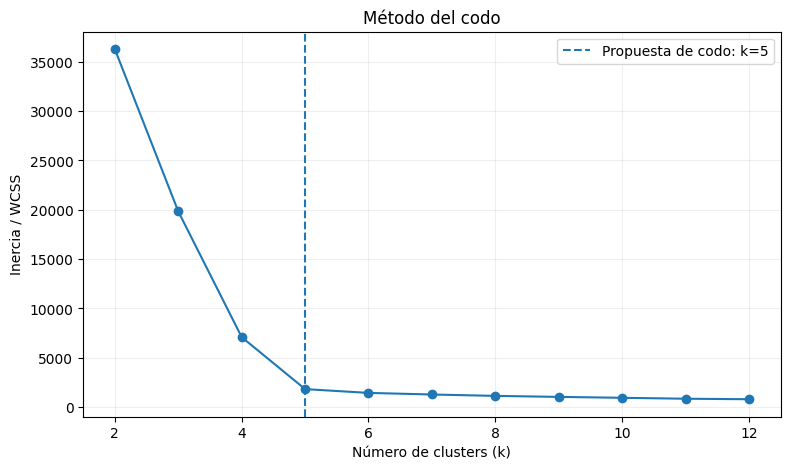

k sugerido por el método del codo: 5


In [8]:
def k_por_codo(ks, inercias):
    x = np.asarray(list(ks), dtype=float)
    y = np.asarray(inercias, dtype=float)

    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    linea = p2 - p1
    puntos = np.column_stack([x, y])

    # Distancia perpendicular a la recta entre los extremos
    distancias = np.abs(
        np.cross(linea, puntos - p1)
    ) / np.linalg.norm(linea)

    return int(x[np.argmax(distancias)])

k_codo = k_por_codo(resultados["k"], resultados["Inercia_WCSS"])

plt.figure(figsize=(9, 5))
plt.plot(resultados["k"], resultados["Inercia_WCSS"], marker="o")
plt.axvline(k_codo, linestyle="--",
            label=f"Propuesta de codo: k={k_codo}")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia / WCSS")
plt.title("Método del codo")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print("k sugerido por el método del codo:", k_codo)


## 7. Método de Silhouette

Se selecciona el `k` que maximiza el promedio de Silhouette. Este es un método interno porque no necesita conocer las etiquetas reales.


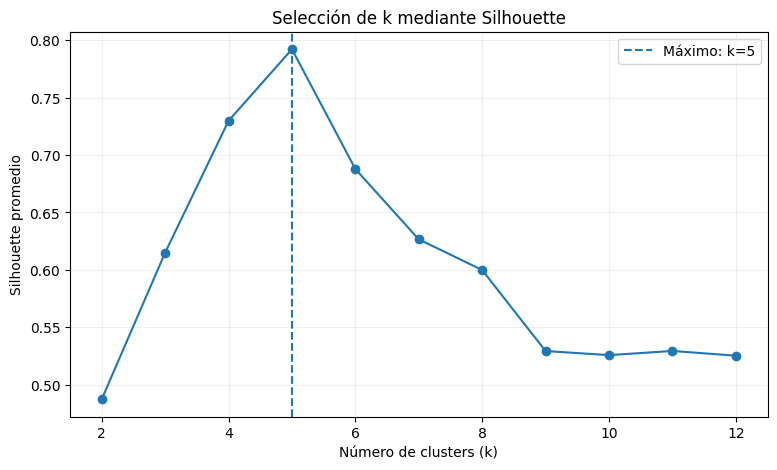

k óptimo según Silhouette: 5
Silhouette máximo: 0.7922


In [9]:
k_silhouette = int(
    resultados.loc[resultados["Silhouette"].idxmax(), "k"]
)
mejor_silhouette = resultados["Silhouette"].max()

plt.figure(figsize=(9, 5))
plt.plot(resultados["k"], resultados["Silhouette"], marker="o")
plt.axvline(k_silhouette, linestyle="--",
            label=f"Máximo: k={k_silhouette}")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette promedio")
plt.title("Selección de k mediante Silhouette")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print(f"k óptimo según Silhouette: {k_silhouette}")
print(f"Silhouette máximo: {mejor_silhouette:.4f}")


## 8. Método basado en las etiquetas verdaderas: Adjusted Rand Index

Como conocemos la procedencia de cada punto, podemos comparar la solución de K-means con las etiquetas reales.

Se utiliza **Adjusted Rand Index (ARI)** porque es independiente de la numeración de los clusters. Un valor cercano a `1` significa una gran coincidencia con el ground truth.


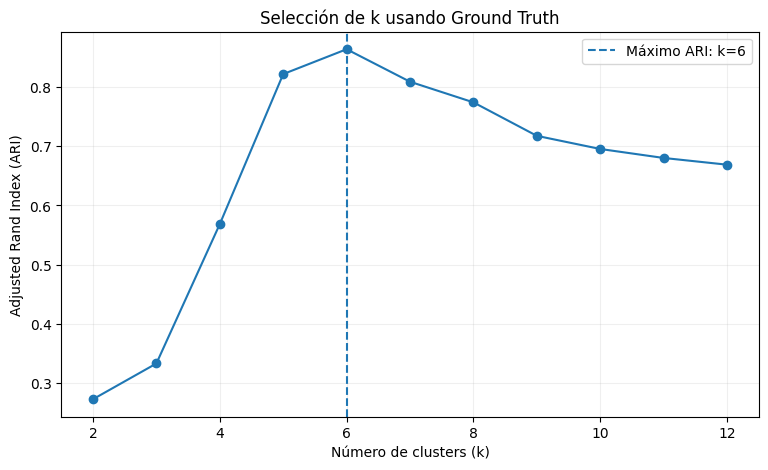

k óptimo según ARI: 6
ARI máximo: 0.8643


In [10]:
k_ground_truth = int(
    resultados.loc[resultados["ARI"].idxmax(), "k"]
)
mejor_ari = resultados["ARI"].max()

plt.figure(figsize=(9, 5))
plt.plot(resultados["k"], resultados["ARI"], marker="o")
plt.axvline(k_ground_truth, linestyle="--",
            label=f"Máximo ARI: k={k_ground_truth}")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.title("Selección de k usando Ground Truth")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print(f"k óptimo según ARI: {k_ground_truth}")
print(f"ARI máximo: {mejor_ari:.4f}")


## 9. Comparación de los tres métodos

Los tres criterios pueden recomendar valores diferentes. Esto es especialmente interesante en este ejercicio porque los grupos tienen diferentes densidades y dos de ellos están parcialmente superpuestos.


In [11]:
comparacion = pd.DataFrame({
    "Método": ["Silhouette", "Codo", "Ground Truth (ARI)"],
    "k recomendado": [k_silhouette, k_codo, k_ground_truth],
    "Valor de referencia": [
        mejor_silhouette,
        resultados.loc[
            resultados["k"] == k_codo, "Inercia_WCSS"
        ].iloc[0],
        mejor_ari
    ]
})

comparacion


,Método,k recomendado,Valor de referencia
0,Silhouette,5,0.792199
1,Codo,5,1835.142565
2,Ground Truth (ARI),6,0.864313


## 10. Visualización de las soluciones seleccionadas

Se muestran las soluciones correspondientes a los valores recomendados por los tres métodos. La comparación visual permite observar qué sucede especialmente en los dos grupos cercanos.


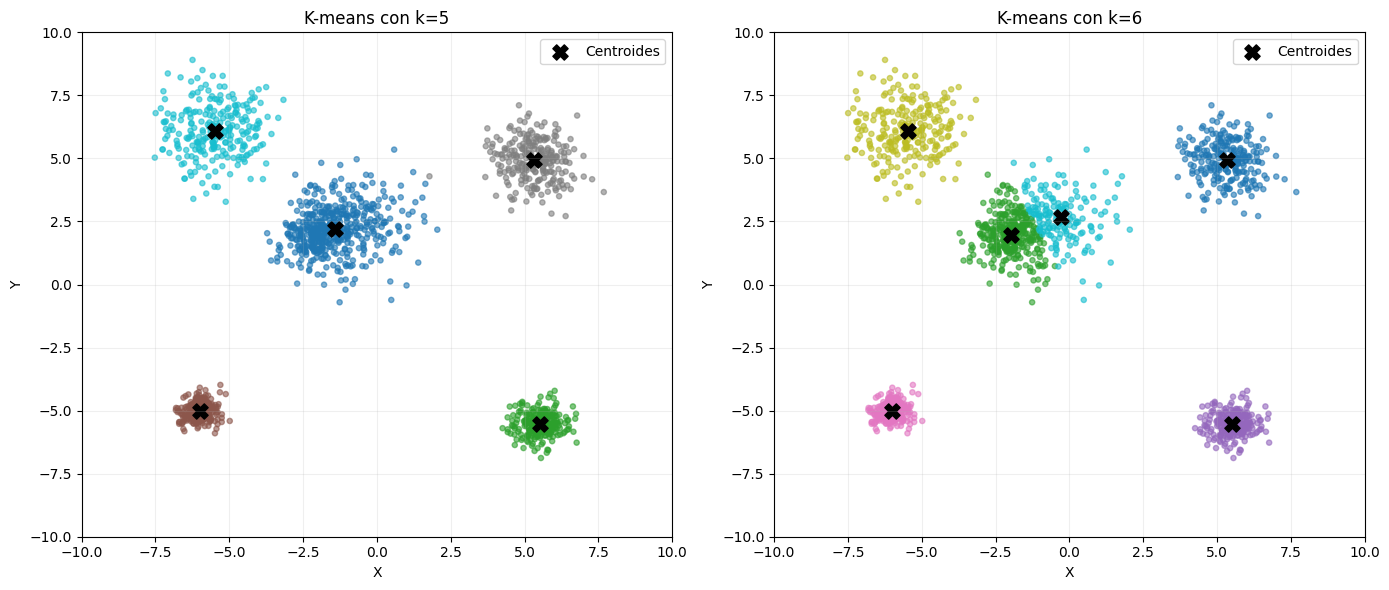

In [12]:
ks_mostrar = sorted(set([k_silhouette, k_codo, k_ground_truth]))

fig, axes = plt.subplots(
    1, len(ks_mostrar),
    figsize=(7 * len(ks_mostrar), 6),
    squeeze=False
)
axes = axes.ravel()

for ax, k in zip(axes, ks_mostrar):
    labels = etiquetas_kmeans[k]
    modelo = modelos[k]

    ax.scatter(
        X_limpio[:, 0], X_limpio[:, 1],
        c=labels, cmap="tab10", s=14, alpha=0.6
    )
    ax.scatter(
        modelo.cluster_centers_[:, 0],
        modelo.cluster_centers_[:, 1],
        c="black", marker="X", s=120,
        label="Centroides"
    )

    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"K-means con k={k}")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()


## 11. Conclusión

El experimento compara tres formas de seleccionar el número de clusters:

- **Codo:** observa cómo disminuye la dispersión interna.
- **Silhouette:** evalúa cohesión y separación sin conocer las etiquetas verdaderas.
- **Ground truth mediante ARI:** compara directamente la solución con las seis etiquetas originales.

El valor final de `k` debe justificarse considerando las tres métricas y las gráficas. El ARI es especialmente útil en este ejercicio porque conocemos la estructura con la que fueron generados los datos, pero en un conjunto real normalmente no se dispone de esas etiquetas.
